In [1]:
DATASET = "block_outliers"
INSTANCE = 16
SEED = 2421
DATASET_KWARGS = {"n": 300, "ell_range": [0.5, 1.0]}

LENGTHSCALE_INIT = 1.0
LENGTHSCALE_MIN = 1.0e-3
LENGTHSCALE_MAX = 1.0e3

NUM_PARTICLES = 32
ALPHA = 1.0
STEP_SIZE = 1.0e-4

SIGMA_INIT = 0.2
SIGMA_MIN = 0.1
SIGMA_MAX = 1.0
SIGMA_LR = 0.1
KERNEL_LR = 0.05

VAL_FRACTION = 0.25
ADAPT_TARGET = None
NUM_ADAPT_STEPS = 800
WARMUP_STEPS = 100
SIGMA_ADAPT_STEPS = 100
KERNEL_ADAPT_STEPS = 100

NUM_SAMPLE_STEPS = 1200
BURN_FRACTION = 0.5
THIN = 2

NUM_FUNCTION_DRAWS = 100

In [2]:
from non_parametric_pro.data.synthetic.block_outliers import (
    BLOCK_OUTLIERS_KWARGS,
    make_block_outlier_instance,
    plot_block_outlier_case,
)
from non_parametric_pro.data.synthetic.heteroskedastic import (
    HETEROSKEDASTIC_KWARGS,
    make_heteroskedastic_instance,
    plot_heteroskedastic_case,
)
from non_parametric_pro.data.synthetic.multimodal import (
    MULTIMODAL_KWARGS,
    make_multimodal_instance,
    plot_multimodal_case,
)
from non_parametric_pro.data.synthetic.well_specified import (
    WELL_SPECIFIED_KWARGS,
    make_well_specified_instance,
    plot_well_specified_case,
)

DATASET_SOURCES = {
    "block_outliers": (
        make_block_outlier_instance,
        plot_block_outlier_case,
        BLOCK_OUTLIERS_KWARGS,
    ),
    "heteroskedastic": (
        make_heteroskedastic_instance,
        plot_heteroskedastic_case,
        HETEROSKEDASTIC_KWARGS,
    ),
    "multimodal": (make_multimodal_instance, plot_multimodal_case, MULTIMODAL_KWARGS),
    "well_specified": (
        make_well_specified_instance,
        plot_well_specified_case,
        WELL_SPECIFIED_KWARGS,
    ),
}

In [3]:
import gpjax as gpx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax as ox
import paramax as px

from non_parametric_pro import ula
from non_parametric_pro import replica_gibbs
from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.inducing import PointInducingBasis
from non_parametric_pro.parameter_adaptation import parameter_adaptation
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.replica_gibbs import parametric_replica_gibbs
from non_parametric_pro.util import (
    cholesky_basis,
    nlpd_gp,
    nlpd_pro,
    posterior_function_draws,
    prediction_basis,
    predictive_moments,
    run_inference_algorithm,
    train_val_split,
)

jax.config.update("jax_enable_x64", True)

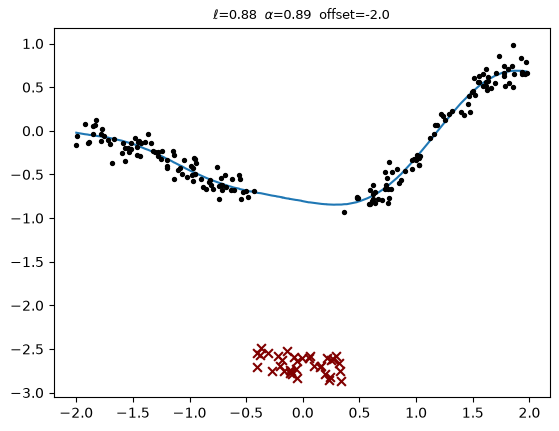

In [4]:
key = jr.PRNGKey(SEED)
instance_keys = jr.split(key, num=20)
instance_key = instance_keys[INSTANCE]

make_instance, plot_case, dataset_kwarg_names = DATASET_SOURCES[DATASET]
dataset_kwargs = {k: v for k, v in DATASET_KWARGS.items() if k in dataset_kwarg_names}
example = make_instance(instance_key, **dataset_kwargs)

x_train, y_train = example.x_train, example.y_train
x_test, y_test = example.x_test, example.y_test

idx = np.argsort(x_test.squeeze())
x_test = x_test[idx]
y_test = y_test[idx]

fig, ax = plt.subplots()
plot_case(ax, example)

In [5]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
exact_gp_kernel = gpx.kernels.RBF(lengthscale=LENGTHSCALE_INIT)

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=exact_gp_kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

gp_posterior, _ = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    verbose=False,
)

gp_latent_train_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_train_dist = gp_posterior.likelihood(gp_latent_train_dist)

gp_predictive_train_mean = gp_predictive_train_dist.mean
gp_predictive_train_std = jnp.sqrt(gp_predictive_train_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

In [56]:
kernel = gpx.kernels.RBF(
    lengthscale=gpx.parameters.SigmoidBounded(
        LENGTHSCALE_INIT, low=LENGTHSCALE_MIN, high=LENGTHSCALE_MAX
    ),
    variance=1.18,
)

basis_full = cholesky_basis(kernel, x_train)

initial_position = jr.normal(key, (basis_full.shape[0], NUM_PARTICLES))

pro_params = ProParameters(
    y=y_train,
    basis=basis_full,
    step_size=None,
    sigma=0.1,
    alpha=1.0,
    residual_std=None,
)
algorithm = parametric_replica_gibbs(pro_logdensity_fn, pro_params)
key, sample_key = jr.split(key)
final_state, (states, info) = run_inference_algorithm(
    rng_key=sample_key,
    inference_algorithm=algorithm,
    num_steps=100,
    initial_position=initial_position,
    progress_bar=True,
)
particles = final_state.position

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:00&lt;?]</div>

In [57]:
test_basis, test_cov = prediction_basis(kernel, x_train, x_train, pro_params)
print(
    "PRO Train NLPD:",
    nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params),
)

test_basis, test_cov = prediction_basis(kernel, x_train, x_test, pro_params)

print(
    "PRO Test NLPD:",
    nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params),
)
print(
    "GP Train NLPD:",
    nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std),
)
print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

PRO Train NLPD: -0.42108867466813377
PRO Test NLPD: -0.8444622593619492
GP Train NLPD: -0.4178884034905783
GP Test NLPD: 11.838467798762759


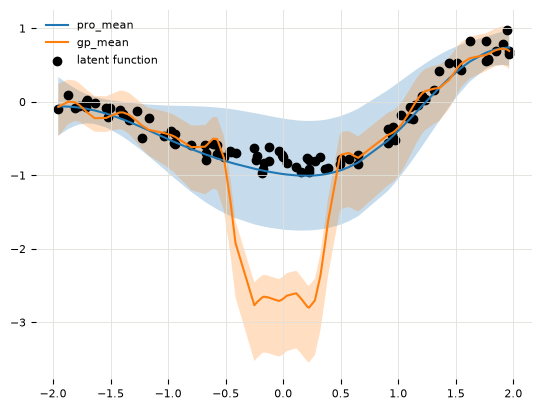

In [58]:
mean, std = predictive_moments(test_basis, particles, noise_std=0.1)

x_plot = x_test.squeeze()

plt.plot(x_plot, mean, label="pro_mean")
plt.plot(x_plot, gp_predictive_mean, label="gp_mean")
plt.fill_between(x_plot, mean - 1.64 * std, mean + 1.64 * std, alpha=0.25)
plt.fill_between(
    x_plot,
    gp_predictive_mean - 1.64 * std,
    gp_predictive_mean + 1.64 * gp_predictive_std,
    alpha=0.25,
)
plt.scatter(x_test.squeeze(), y_test.squeeze(), color="black", label="latent function")
plt.legend()
plt.show()

In [59]:
test_basis, test_cov = prediction_basis(kernel, x_train, x_test, pro_params)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=NUM_FUNCTION_DRAWS,
    jitter=pro_params.jitter,
)

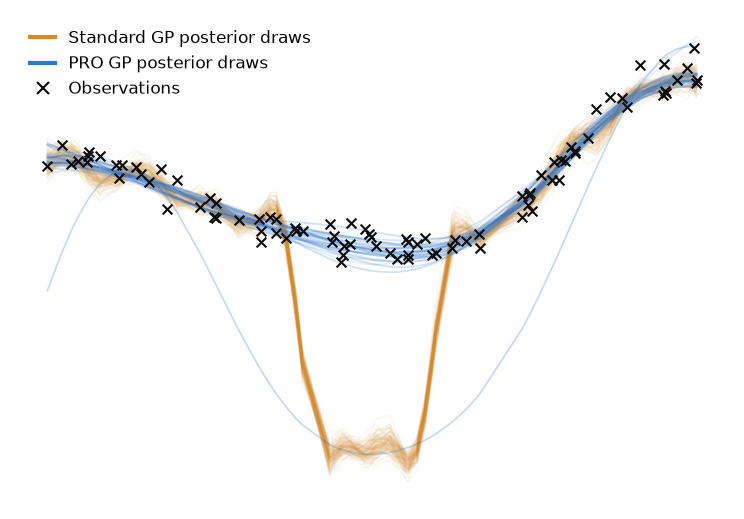

In [60]:
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.size": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.spines.bottom": False,
        "axes.grid": True,
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
    }
)

pro_color = "#2a78d6"
gp_color = "#d68a2a"
obs_color = "#0b0b0b"
num_draws = draws.shape[1]

key, gp_draw_key = jr.split(key)
gp_draws = np.asarray(
    gp_latent_dist.sample(gp_draw_key, sample_shape=(num_draws,))
).T  # (N_test, num_draws)

order = np.argsort(x_test.squeeze())
x_sorted = x_test.squeeze()[order]
y_sorted = y_test.squeeze()[order]
pro_draws_sorted = np.asarray(draws)[order]
gp_draws_sorted = gp_draws[order]

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=150)

ax.plot(
    x_sorted,
    gp_draws_sorted,
    color=gp_color,
    alpha=0.06,
    linewidth=0.8,
    rasterized=True,
)
ax.plot(
    x_sorted,
    pro_draws_sorted,
    color=pro_color,
    alpha=0.06,
    linewidth=0.8,
    rasterized=True,
)
ax.scatter(
    x_sorted, y_sorted, color=obs_color, marker="x", s=22, linewidths=1.0, zorder=5
)

legend_handles = [
    Line2D(
        [0], [0], color=gp_color, linewidth=2.0, label="Standard GP posterior draws"
    ),
    Line2D([0], [0], color=pro_color, linewidth=2.0, label="PRO GP posterior draws"),
    Line2D(
        [0],
        [0],
        color=obs_color,
        marker="x",
        linestyle="None",
        markersize=6,
        label="Observations",
    ),
]
ax.legend(handles=legend_handles, loc="best", handlelength=1.5)

ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()